In [28]:
import numpy as np
import matplotlib.pyplot as plt
import math

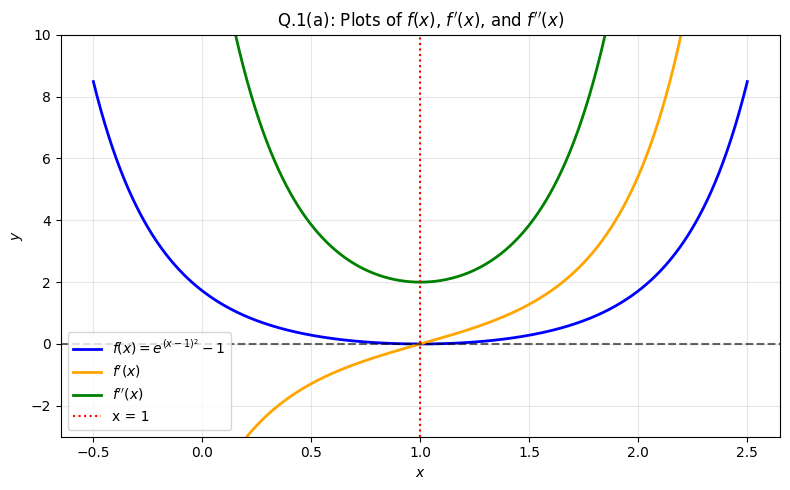

In [29]:

#a part
x = np.linspace(-0.5, 2.5, 1000)

f = np.exp((x - 1)**2) - 1
df = 2 * (x - 1) * np.exp((x - 1)**2)
d2f = 2 * np.exp((x - 1)**2) * (1 + 2 * (x - 1)**2)

plt.figure(figsize=(8, 5))
plt.plot(x, f, label=r"$f(x) = e^{(x-1)^2} - 1$", color="blue", linewidth=2)
plt.plot(x, df, label=r"$f'(x)$", color="orange", linewidth=2)
plt.plot(x, d2f, label=r"$f''(x)$", color="green", linewidth=2)

plt.axhline(0, color="black", linestyle="--", alpha=0.6)
plt.axvline(1, color="red", linestyle=":", label="x = 1")

plt.ylim(-3, 10)
plt.title("Q.1(a): Plots of $f(x)$, $f'(x)$, and $f''(x)$", fontsize=12)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

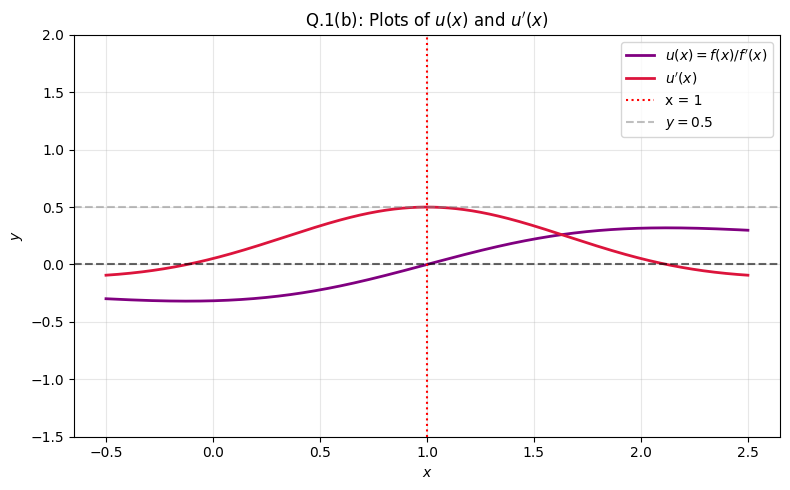

In [30]:
#b part
x = np.linspace(-0.5, 2.5, 1000)

f = np.exp((x - 1)**2) - 1
df = 2 * (x - 1) * np.exp((x - 1)**2)
d2f = 2 * np.exp((x - 1)**2) * (1 + 2 * (x - 1)**2)

u = np.where(np.abs(x - 1) < 1e-9, 0.0, f / df)
du = 1 - (f * d2f) / (df**2)
du = np.where(np.abs(x - 1) < 1e-9, 0.5, du)


plt.figure(figsize=(8, 5))
plt.plot(x, u, label=r"$u(x) = f(x)/f'(x)$", color="purple", linewidth=2)
plt.plot(x, du, label=r"$u'(x)$", color="crimson", linewidth=2)

plt.axhline(0, color="black", linestyle="--", alpha=0.6)
plt.axvline(1, color="red", linestyle=":", label="x = 1")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="$y = 0.5$")

plt.ylim(-1.5, 2.0)
plt.title("Q.1(b): Plots of $u(x)$ and $u'(x)$", fontsize=12)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#c part
def f(x):
    return math.exp((x - 1.0)**2) - 1.0

def u(x):
    if abs(x - 1.0) < 1e-12:
        return 0.0
    return (1.0 - math.exp(-((x - 1.0)**2))) / (2.0 * (x - 1.0))

def standard_secant(x_minus1, x0, tol=1e-6, max_iter=100):
    x_prev, x_curr = x_minus1, x0
    for k in range(1, max_iter + 1):
        f_prev, f_curr = f(x_prev), f(x_curr)
        x_next = x_curr - f_curr * (x_curr - x_prev) / (f_curr - f_prev)
        if abs(x_next - x_curr) < tol:
            return x_next, k
        x_prev, x_curr = x_curr, x_next
    return x_next, k

def modified_secant_u(x_minus1, x0, tol=1e-6, max_iter=100):
    x_prev, x_curr = x_minus1, x0
    for k in range(1, max_iter + 1):
        u_prev, u_curr = u(x_prev), u(x_curr)
        if abs(u_curr - u_prev) < 1e-15:
            return None, max_iter + 1
            
        x_next = x_curr - u_curr * (x_curr - x_prev) / (u_curr - u_prev)
        
        if abs(x_next) > 1000:
            return None, max_iter + 1
            
        if abs(x_next - x_curr) < tol:
            return x_next, k
            
        x_prev, x_curr = x_curr, x_next
    return None, max_iter + 1

max_limit = 100
std_root, std_iters = standard_secant(-0.5, 0.0, max_iter=max_limit)
mod_root, mod_iters = modified_secant_u(-0.5, 0.0, max_iter=max_limit)

print("Standard Secant:")
print(f"Root: {std_root:.7f}")
print(f"Iterations: {std_iters}\n")

print("Modified Secant:")
if mod_iters > max_limit:
    print("Iterations: Exceeds max iterations")
else:
    print(f"Root: {mod_root:.7f}")
    print(f"Iterations: {mod_iters}")

Standard Secant:
Root: 0.9999989
Iterations: 30

Modified Secant:
Iterations: Exceeds max iterations
